# Movie Gross Prediction: Machine Learning Modeling
In this notebook, we focus strictly on building a predictive model for movie gross revenue, handling preprocessing, target encoding, and model validation.

In [2]:
# --- 1. SETUP & DATA LOADING ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('../datasets/movies.csv')

# Drop rows with missing financials
df = df.dropna(subset=['budget', 'gross'])

# Basic cleaning: minor imputation
if 'rating' in df.columns:
    df['rating'] = df['rating'].fillna('Unrated')
df = df.dropna()

# Standardize data types
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

# Extract correct release year
df['year_correct'] = df['released'].astype(str).str.extract(r'(\d{4})')
df['year_correct'] = pd.to_numeric(df['year_correct'], errors='coerce')
df = df.dropna(subset=['year_correct'])  # Drop missing years

print(f"Data ready for machine learning. Shape: {df.shape}")

Data ready for machine learning. Shape: (5432, 16)


## Feature Selection & Data Splitting
We will organize our predictive features and isolate the target variable (`gross`). It is critical to split the data *before* any statistical encoding to prevent data leakage.

In [3]:
# --- 2. DATA SPLITTING & PREPARATION ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ml_df = df.copy()

features = ['budget', 'score', 'votes', 'runtime', 'year_correct', 'rating', 'genre', 'director', 'writer']
target = 'gross'

X = ml_df[features].copy()
y = ml_df[target].copy()

# Split data BEFORE encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Explicit copies to ensure safety
X_train = X_train.copy()
X_test = X_test.copy()

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (4345, 9)
Testing Features Shape: (1087, 9)


## Feature Encoding
We use standard Label Encoding for low-cardinality variables (`rating`, `genre`) and mathematically-sound Target Encoding for high-cardinality features (`director`, `writer`) to group them efficiently without dimensional explosion.

In [4]:
# --- 3. ENCODING: LOW-CARDINALITY FEATURES ---
low_card_features = ['rating', 'genre']

for col in low_card_features:
    encoder = LabelEncoder()
    
    # Fit ONLY on training data
    encoder.fit(X_train[col].astype(str))
    
    # Add an '<UNSEEN>' class safely
    classes = list(encoder.classes_)
    if '<UNSEEN>' not in classes:
        classes.append('<UNSEEN>')
    encoder.classes_ = np.array(classes)
    
    # Transform training data
    X_train[col] = encoder.transform(X_train[col].astype(str))
    
    # Map unseen test categories to fallback
    known_classes = set(encoder.classes_)
    X_test[col] = X_test[col].astype(str).apply(lambda x: x if x in known_classes else '<UNSEEN>')
    X_test[col] = encoder.transform(X_test[col])


# --- 4. ENCODING: HIGH-CARDINALITY FEATURES ---
def target_encode(X_tr, y_tr, X_te, cols):
    """
    Applies target encoding based strictly on training data statistics.
    Replaces qualitative categories with the historical mean gross revenue.
    """
    global_mean = y_tr.mean()
    
    for col in cols:
        target_map = y_tr.groupby(X_tr[col]).mean().to_dict()
        
        X_tr[f'{col}_encoded'] = X_tr[col].map(target_map).fillna(global_mean)
        X_te[f'{col}_encoded'] = X_te[col].map(target_map).fillna(global_mean)
        
        X_tr.drop(columns=[col], inplace=True)
        X_te.drop(columns=[col], inplace=True)
        
    return X_tr, X_te

high_card_features = ['director', 'writer']

X_train, X_test = target_encode(X_train, y_train, X_test, high_card_features)

display(X_train.head(3))

,budget,score,votes,runtime,year_correct,rating,genre,director_encoded,writer_encoded
7100,13000000,7.2,92000.0,107.0,2018,5,4,24646055.0,2.464606e+07
2757,12000000,6.1,15000.0,109.0,1995,5,9,11078388.0,1.547326e+07
4144,38000000,5.2,62000.0,100.0,2002,3,0,96996331.0,7.214173e+07


## Model Training & Evaluation (Regression)
We will train a baseline Random Forest Regressor and evaluate it using $R^2$, $RMSE$, and $MAE$.

--- Training Baseline Model ---

--- Regression Evaluation Metrics ---
R² Score : 0.5785
RMSE     : $120,272,675.32
MAE      : $62,264,613.02

Interpretation:
- The model explains ~57.8% of the variance in movie gross revenue (R² = 0.58).
- On average, predictions deviate from actual earnings by ~$62,264,613.02 (MAE).


c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


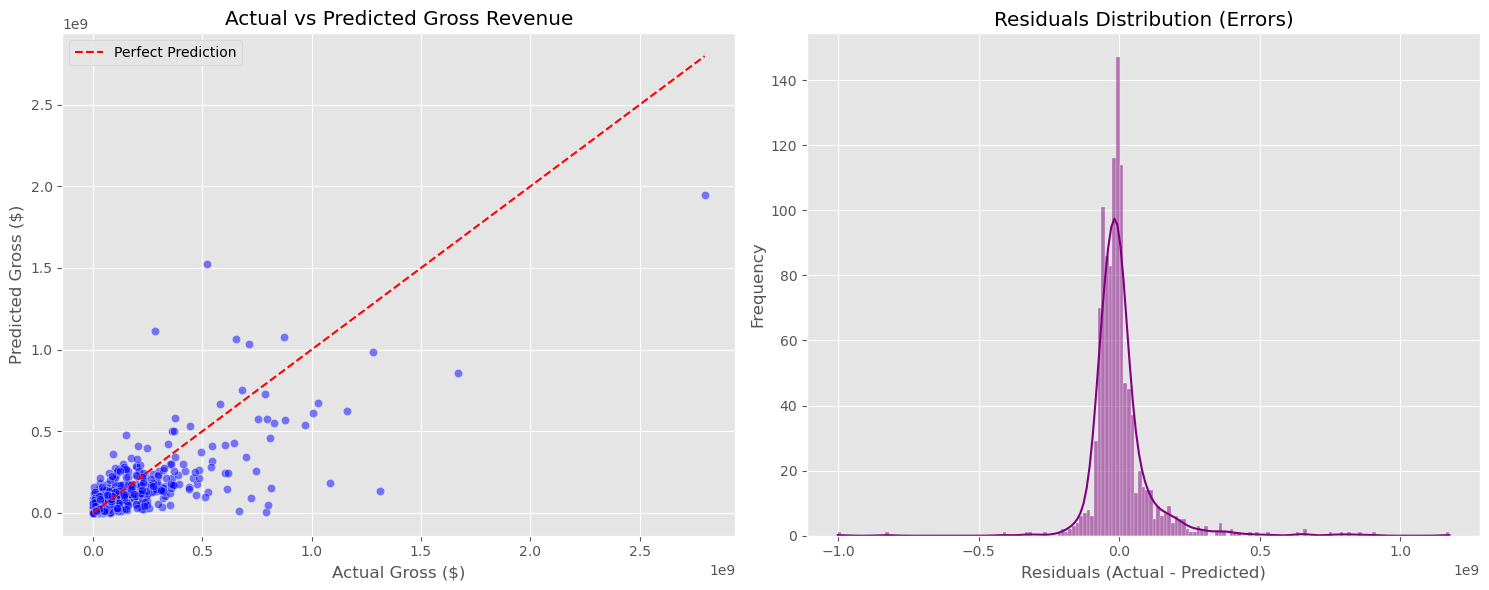


--- Sample: Actual vs Predicted (First 5 Rows) ---


,Actual Gross,Predicted Gross,Difference (Error)
0,"$13,313,581.00","$93,760,606.34","$-80,447,025.34"
1,"$16,457,494.00","$6,643,089.18","$9,814,404.82"
2,"$84,565,230.00","$122,357,474.51","$-37,792,244.51"
3,"$31,853,080.00","$63,675,104.79","$-31,822,024.79"
4,"$970,766,005.00","$539,636,744.01","$431,129,260.99"


In [5]:
# --- 5. TRAIN MODEL & GENERATE PREDICTIONS ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("--- Training Baseline Model ---")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# --- 6. REGRESSION METRICS ---
print("\n--- Regression Evaluation Metrics ---")
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : ${rmse:,.2f}")
print(f"MAE      : ${mae:,.2f}")

print(f"\nInterpretation:")
print(f"- The model explains ~{r2*100:.1f}% of the variance in movie gross revenue (R² = {r2:.2f}).")
print(f"- On average, predictions deviate from actual earnings by ~${mae:,.2f} (MAE).")

# --- 7. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=axes[0], color='blue')
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction')

axes[0].set_title('Actual vs Predicted Gross Revenue')
axes[0].set_xlabel('Actual Gross ($)')
axes[0].set_ylabel('Predicted Gross ($)')
axes[0].legend()

# Plot 2: Residuals Analysis
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')

axes[1].set_title('Residuals Distribution (Errors)')
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# --- 8. BONUS: SAMPLE COMPARISON ---
print("\n--- Sample: Actual vs Predicted (First 5 Rows) ---")
sample_comparison = pd.DataFrame({
    'Actual Gross': y_test.values[:5],
    'Predicted Gross': y_pred[:5],
    'Difference (Error)': residuals.values[:5]
})
display(sample_comparison.style.format("${:,.2f}"))